# Core

> bioMONAI core functions


In [ ]:
#| default_exp core

In [ ]:
#| hide
from nbdev.showdoc import *
from fastcore.test import *

## Imports

This section includes essential imports used throughout the core library, providing foundational tools for data handling, model training, and evaluation. Key imports cover areas such as data blocks, data loaders, custom loss functions, optimizers, callbacks, and logging. 


In [ ]:
#| export

# =================================
# Scientific / data
# =================================
import numpy as np
import pandas as pd

# =================================
# Visualization
# =================================
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# =================================
# Imaging
# =================================
# from skimage import util

# =================================
# PyTorch
# =================================
import torch.optim as toptim
from torch.cuda import is_available as is_cuda_available
from torch.nn.init import kaiming_normal_

# =================================
# fastai
# =================================
# import fastai.losses
# import fastai.metrics
# import fastai.optimizer

from fastai.callback.core import Callback
from fastai.callback.all import *

from fastai.data.all import (
    DataLoaders, Path, trainable_params, delegates,
    hasattrs, List, L, Normalize
)

from fastai.optimizer import Adam, OptimWrapper, Optimizer

from fastai.vision.all import (
    Any, BypassNewMeta, CSVLogger, ClassificationInterpretation,
    DataBlock, DisplayedTransform, Learner, ShowGraphCallback,
    create_vision_model, create_timm_model, default_split,
    get_c, ifnone, minimum, model_meta, slide, steep, store_attr, valley
)

# =================================
# fastcore
# =================================
from fastcore.script import risinstance

# =================================
# bioMONAI
# =================================
from bioMONAI.utils import *
from bioMONAI.datasets import download_medmnist

In [ ]:
show_doc(DataBlock)


---

[source](https://github.com/fastai/fastai/blob/main/fastai/data/block.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### DataBlock

```python

def DataBlock(
    blocks:list=None, # One or more `TransformBlock`s
    dl_type:TfmdDL=None, # Task specific `TfmdDL`, defaults to `block`'s dl_type or`TfmdDL`
    getters:list=None, # Getter functions applied to results of `get_items`
    n_inp:int=None, # Number of inputs
    item_tfms:list=None, # `ItemTransform`s, applied on an item
    batch_tfms:list=None, # `Transform`s or `RandTransform`s, applied by batch
    get_items:NoneType=None, splitter:NoneType=None, get_y:NoneType=None, get_x:NoneType=None
):


```

*Generic container to quickly build `Datasets` and `DataLoaders`.*

In [ ]:
#| export
DataBlock = DataBlock

The `DataBlock` class Datablock comes from the fastai library and builds datasets and dataloaders from blocks, acting as a container for creating data processing pipelines, allowing easy customization of datasets and data loaders. It enables the definition of item transformations, batch transformations, and dataset split methods, streamlining data preprocessing and loading across various stages of model training.


In [ ]:
show_doc(DataLoaders)


---

[source](https://github.com/fastai/fastai/blob/main/fastai/data/core.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### DataLoaders

```python

def DataLoaders(
    loaders:VAR_POSITIONAL, # `DataLoader` objects to wrap
    path:str | Path='.', # Path to store export objects
    device:NoneType=None, # Device to put `DataLoaders`
):


```

*Basic wrapper around several `DataLoader`s.*

In [ ]:
#| export
DataLoaders = DataLoaders

The `DataLoaders` class is a container for managing training and validation datasets. This class wraps one or more `DataLoader` instances, ensuring seamless data management and transfer across devices (CPU or GPU) for efficient training and evaluation.


In [ ]:
show_doc(Learner)


---

[source](https://github.com/fastai/fastai/blob/main/fastai/learner.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### Learner

```python

def Learner(
    dls:DataLoaders, # `DataLoaders` containing fastai or PyTorch `DataLoader`s
    model:Callable, # PyTorch model for training or inference
    loss_func:Callable | None=None, # Loss function. Defaults to `dls` loss
    opt_func:Optimizer | OptimWrapper=Adam, # Optimization function for training
    lr:float | slice=0.001, # Default learning rate
    splitter:Callable=trainable_params, # Split model into parameter groups. Defaults to one parameter group
    cbs:Callback | MutableSequence | None=None, # `Callback`s to add to `Learner`
    metrics:Callable | MutableSequence | None=None, # `Metric`s to calculate on validation set
    path:str | Path | None=None, # Parent directory to save, load, and export models. Defaults to `dls` `path`
    model_dir:str | Path='models', # Subdirectory to save and load models
    wd:float | int | None=None, # Default weight decay
    wd_bn_bias:bool=False, # Apply weight decay to normalization and bias parameters
    train_bn:bool=True, # Train frozen normalization layers
    moms:tuple=(0.95, 0.85, 0.95), # Default momentum for schedulers
    default_cbs:bool=True, # Include default `Callback`s
):


```

*Group together a `model`, some `dls` and a `loss_func` to handle training*

In [ ]:
#| export
Learner = Learner

The `Learner` class is the main interface for training machine learning models, encapsulating the model, data, loss function, optimizer, and training metrics. It simplifies the training process by providing built-in functionality for model evaluation, hyperparameter tuning, and training loop customization, allowing you to focus on model optimization.


In [ ]:
#| export
OptimWrapper = OptimWrapper
Adam = Adam
Optimizer = Optimizer

In [ ]:
show_doc(OptimWrapper)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/optimizer.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### OptimWrapper

```python

def OptimWrapper(
    params:Tensor | Iterable=None, # Model parameters. Don't set if using a built optimizer
    opt:Callable | torch.optim.Optimizer=None, # A torch optimizer constructor, or an already built optimizer
    hp_map:dict=None, # A dictionary converting PyTorch optimizer keys to fastai's `Optimizer` keys. Defaults to `pytorch_hp_map`
    convert_groups:bool=True, # Convert parameter groups from splitter or pass unaltered to `opt`
    kwargs:VAR_KEYWORD
):


```

*A wrapper class for existing PyTorch optimizers*

In [ ]:
show_doc(Adam)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/optimizer.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### Adam

```python

def Adam(
    params:Tensor | Iterable, # Model parameters
    lr:float | slice, # Default learning rate
    mom:float=0.9, # Gradient moving average (β1) coefficient
    sqr_mom:float=0.99, # Gradient squared moving average (β2) coefficient
    eps:float=1e-05, # Added for numerical stability
    wd:Real=0.01, # Optional weight decay (true or L2)
    decouple_wd:bool=True, # Apply true weight decay (AdamW) or L2 regularization (Adam)
)->Optimizer:


```

*A Adam/AdamW `Optimizer`*

In [ ]:
show_doc(Optimizer)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/optimizer.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### Optimizer

```python

def Optimizer(
    params:Tensor | Iterable, # Model parameters
    cbs:Callable | MutableSequence, # `Optimizer` step callbacks
    defaults:VAR_KEYWORD
):


```

*Base optimizer class for the fastai library, updating `params` with `cbs`*

## Engine

The engine module provides advanced functionalities for model training, including configurable training loops and evaluation functions tailored for bioinformatics applications. This module is significantly valuable when there is a need for specific workflows and pipelines that meet specific requirements. For this reason, the classes fastTrainer and visionTrainer have been created, providing tailored implementations inheriting from the Learner class. 


FastTrainer is used for training models in bioinformatics applications, where specific loss functions and optimizers oriented to biological data can be used. 

In [ ]:
#| export
class fastTrainer(Learner):
    """
    A custom implementation of the FastAI Learner class for training models in bioinformatics applications.

    """
    
    def __init__(self, 
                 dataloaders: DataLoaders, # The DataLoader objects containing training and validation datasets.
                 model: callable, # A callable model that will be trained on the dataset.
                 loss_fn: Any | None = None, # The loss function to optimize during training. If None, defaults to a suitable default.
                 optimizer: Optimizer | OptimWrapper = Adam, # The optimizer function to use. Defaults to Adam if not specified.
                 lr: float | slice = 1e-3, # Learning rate for the optimizer. Can be a float or a slice object for learning rate scheduling.
                 splitter: callable = trainable_params, # 
                 callbacks: Callback | MutableSequence | None = None, # A callable that determines which parameters of the model should be updated during training.
                 metrics: Any | MutableSequence | None = None, # Optional list of callback functions to customize training behavior.
                 csv_log: bool = False, # Metrics to evaluate the performance of the model during training.
                 show_graph: bool = True, # Whether to log training history to a CSV file. If True, logs will be appended to 'history.csv'.
                 show_summary: bool = False, # The base directory where models are saved or loaded from. Defaults to None.
                 find_lr: bool = False, # Subdirectory within the base path where trained models are stored. Default is 'models'.
                 find_lr_fn = valley, # Weight decay factor for optimization. Defaults to None.
                 path: str | Path | None = None, # Whether to apply weight decay to batch normalization and bias parameters.
                 model_dir: str | Path = 'models', # Whether to update the batch normalization statistics during training.
                 wd: float | int | None = None, 
                 wd_bn_bias: bool = False, 
                 train_bn: bool = True, 
                 moms: tuple = (0.95,0.85,0.95), # Tuple of tuples representing the momentum values for different layers in the model. Defaults to FastAI's default settings if not specified.
                 default_cbs: bool = True, # Automatically include default callbacks such as ShowGraphCallback and CSVLogger.
                 ):
        cbs = callbacks if callbacks is not None else []  # Ensure cbs is a list
        if default_cbs:
            if show_graph:
                cbs.append(ShowGraphCallback())
            if csv_log:
                cbs.append(CSVLogger(fname='history.csv', append=False))
        
        super().__init__(dataloaders, model, loss_fn, optimizer, lr, splitter, cbs, metrics, path, model_dir, wd, wd_bn_bias, train_bn, moms)
        
        if show_summary:
                print(self.summary())
        if find_lr:
                lr = self.lr_find(suggest_funcs=find_lr_fn)
                self.lr = float('%.1g'%(lr))
                print('Inferred learning rate: ', self.lr)
        

    @classmethod
    def from_yaml(cls, dataloaders, model, yaml_path):
        """
        Method to read from a YAML file and obtain the parameters for FastTrainer.
        """
        # Read the configuration from the yaml file and replace None strings with Nonetype values
        config = read_yaml(yaml_path)
        config = {key: (None if value == "None" else value) for key, value in config.items()}

        
        
        # OBTAIN THE LOSS FUNCTION
        loss_str = config.get('loss_fn', None)
        # Look for the loss function within the variables and check if its valid
        if loss_str == None:
            loss_func = None
        else:
            lf_cls = globals().get(loss_str) or getattr(fm, loss_str, None)
            if lf_cls is None:
                raise ValueError(f"Loss function '{loss_str}' not found or invalid.")
            loss_func = lf_cls()


        # OBTAIN THE OPTIMIZER
        opt_str = config.get('optimizer', 'Adam')
        # Look for the optimizer within the variables and check if its valid
        if isinstance(opt_str, str):
            opt_cls = globals().get(opt_str, None)
            if opt_cls is None and hasattr(fastai.optimizer, opt_str):
                opt_cls = getattr(fastai.optimizer, opt_str)
            if opt_cls is None and hasattr(toptim, opt_str):
                opt_cls = getattr(toptim, opt_str)
            if opt_cls is None or not callable(opt_cls):
                raise ValueError(f"Optimizer '{opt_str}' not found or invalid.")
            opt_func = opt_cls


        # OBTAIN THE METRICS
        metrics_cfg = config.get('metrics', [])
        # Look for the metrics within the variables and check if they are valid
        valid_metrics = []
        if metrics_cfg == None:
            valid_metrics = None
        else:
            valid_metrics = dictlist_to_funclist(metrics_cfg)

        # OBTAIN THE CALLBACKS
        callbacks = []
        cbs = config.get('callbacks', [])
        callbacks = dictlist_to_funclist(cbs)

        # OBTAIN THE SPLITTER
        splitter_str = config.get('splitter', trainable_params)
        if isinstance(splitter_str, str):
            splitter_func = globals().get(splitter_str) or getattr(fastai.learner, splitter_str, None)
        elif splitter_str is None:
            splitter_func = trainable_params 
        else:
                splitter_func = splitter_str


        # OBTAIN OTHER PARAMETERS FROM THE YAML CONFIGURATION 
        lr = config.get('lr', 1e-3)
        csv_log = config.get('csv_log', False)
        show_graph = config.get('show_graph', True)
        show_summary = config.get('show_summary', False)
        path = config.get('path', None)
        model_dir = config.get('model_dir', 'models')
        wd = config.get('wd', None)
        wd_bn_bias = config.get('wd_bn_bias', False)
        train_bn = config.get('train_bn', True)
        moms = config.get('moms', (0.95,0.85,0.95))
   


        # Return all the parameters
        return cls(dataloaders = dataloaders, model = model, loss_fn = loss_func, optimizer = opt_func,
            lr = lr, splitter = splitter_func, callbacks = callbacks, metrics = valid_metrics, path = path,
            model_dir = model_dir, wd = wd, wd_bn_bias = wd_bn_bias, train_bn = train_bn, moms = moms,
            csv_log = csv_log, show_graph = show_graph, show_summary = show_summary          
        )        

#### Example: train a model with configuration from a YAML file.

In [ ]:
from monai.networks.nets import SEResNet50
from bioMONAI.data import BioDataLoaders
from bioMONAI.metrics import BalancedAccuracy, Precision, accuracy

ImportError: cannot import name 'tensor' from 'bioMONAI.core' (/home/biagio/bioMONAI/bioMONAI/core.py)

In [ ]:
# Import the data
image_path = '_data'
info = download_medmnist('bloodmnist', image_path, download_only=True)
batch_size = 32
path = Path(image_path)/'bloodmnist'
path_train = path/'train'
path_val = path/'val'

Dataset 'bloodmnist' is already downloaded and available in '_data/bloodmnist'.


In [ ]:
# Define the dataloader
data = BioDataLoaders.class_from_folder(
    path,
    train='train',
    valid='val',
    vocab=info['label'],
    batch_tfms=None,
    bs=batch_size)

# Define the model
model = SEResNet50(spatial_dims=2,
                   in_channels=3,   
                   num_classes=8)    

epoch,train_loss,valid_loss,accuracy,balanced_accuracy_score,precision_score,time
0,0.801488,0.537181,0.793808,0.734412,0.795006,00:23


Better model found at epoch 0 with accuracy value: 0.7938084006309509.


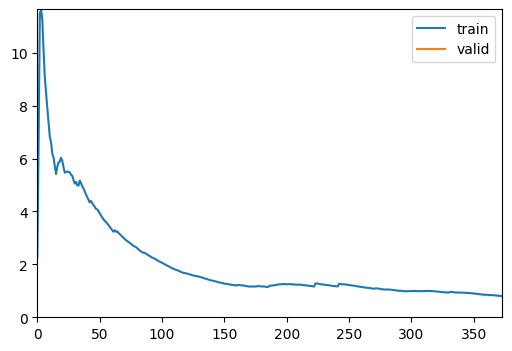

In [ ]:
# Define the trainer with configuration from a YAML file 
yaml_path = "./data_examples/sample_config.yml"
trainer = fastTrainer.from_yaml(data, model, yaml_path)

# Train the model
trainer.fit(1)


In [ ]:
print(trainer.recorder.metric_names)

['epoch', 'train_loss', 'valid_loss', 'accuracy', 'balanced_accuracy_score', 'precision_score', 'time']


In [ ]:
#| export
def _add_norm(dls, meta, pretrained, n_in=3):
    if not pretrained: return
    stats = meta.get('stats')
    if stats is None: return
    if n_in != len(stats[0]): return
    if not dls.after_batch.fs.filter(risinstance(Normalize)):
        dls.add_tfms([Normalize.from_stats(*stats)],'after_batch')

def _timm_norm(dls, cfg, pretrained, n_in=3):
    if not pretrained: return
    if n_in != len(cfg['mean']): return
    if not dls.after_batch.fs.filter(risinstance(Normalize)):
        tfm = Normalize.from_stats(cfg['mean'],cfg['std'])
        dls.add_tfms([tfm],'after_batch')

VisionTrainer is used for computer vision applications, where image normalization or other computer vision related settings are needed.

In [ ]:
#| export
@delegates(create_vision_model)
def visionTrainer(  dataloaders: DataLoaders, # The DataLoader objects containing training and validation datasets.
                    model: callable, # A callable model that will be trained on the dataset.
                    normalize=True, 
                    n_out=None, 
                    pretrained=True, 
                    weights=None,
                    # Trainer args
                    loss_fn: Any | None = None, # The loss function to optimize during training. If None, defaults to a suitable default.
                    optimizer: Optimizer | OptimWrapper = Adam, # The optimizer function to use. Defaults to Adam if not specified.
                    lr: float | slice = 1e-3, # Learning rate for the optimizer. Can be a float or a slice object for learning rate scheduling.
                    splitter: callable = trainable_params, # 
                    callbacks: Callback | MutableSequence | None = None, # A callable that determines which parameters of the model should be updated during training.
                    metrics: Any | MutableSequence | None = None, # Optional list of callback functions to customize training behavior.
                    csv_log: bool = False, # Metrics to evaluate the performance of the model during training.
                    show_graph: bool = True, # Whether to log training history to a CSV file. If True, logs will be appended to 'history.csv'.
                    show_summary: bool = False, # The base directory where models are saved or loaded from. Defaults to None.
                    find_lr: bool = False, # Subdirectory within the base path where trained models are stored. Default is 'models'.
                    find_lr_fn = valley, # Weight decay factor for optimization. Defaults to None.
                    path: str | Path | None = None, # Whether to apply weight decay to batch normalization and bias parameters.
                    model_dir: str | Path = 'models', # Whether to update the batch normalization statistics during training.
                    wd: float | int | None = None, 
                    wd_bn_bias: bool = False, 
                    train_bn: bool = True, 
                    moms: tuple = (0.95,0.85,0.95), # Tuple of tuples representing the momentum values for different layers in the model. Defaults to FastAI's default settings if not specified.
                    default_cbs: bool = True, # Automatically include default callbacks such as ShowGraphCallback and CSVLogger.
                    # model & head args
                    cut=None, 
                    init=kaiming_normal_, 
                    custom_head=None, 
                    concat_pool=True, 
                    pool=True,
                    lin_ftrs=None, 
                    ps=0.5, 
                    first_bn=True, 
                    bn_final=False, 
                    lin_first=False, 
                    y_range=None, 
                    **kwargs):
    "Build a vision trainer from `dataloaders` and `model`"
    if n_out is None: n_out = get_c(dataloaders)
    assert n_out, "`n_out` is not defined, and could not be inferred from data, set `dataloaders.c` or pass `n_out`"
    meta = model_meta.get(model, {'cut':cut, 'split':default_split})
    model_args = dict(init=init, custom_head=custom_head, concat_pool=concat_pool, pool=pool, lin_ftrs=lin_ftrs, ps=ps,
                      first_bn=first_bn, bn_final=bn_final, lin_first=lin_first, y_range=y_range, **kwargs)
    n_in = kwargs['n_in'] if 'n_in' in kwargs else 3
    if isinstance(model, str):
        model,cfg = create_timm_model(model, n_out, default_split, pretrained, **model_args)
        if normalize: _timm_norm(dataloaders, cfg, pretrained, n_in)
    else:
        if normalize: _add_norm(dataloaders, meta, pretrained, n_in)
        model = create_vision_model(model, n_out, pretrained=pretrained, weights=weights, **model_args)

    splitter = ifnone(splitter, meta['split'])
    trainer = fastTrainer(dataloaders, model, loss_fn=loss_fn, optimizer=optimizer, lr=lr, splitter=splitter, callbacks=callbacks, csv_log=csv_log, 
                        show_graph=show_graph, show_summary=show_summary, find_lr=find_lr, find_lr_fn=find_lr_fn, metrics=metrics, path=path, 
                        model_dir=model_dir, wd=wd, wd_bn_bias=wd_bn_bias, train_bn=train_bn, moms=moms, default_cbs=default_cbs)
    if pretrained: trainer.freeze()
    # keep track of args for loggers
    store_attr('model,normalize,n_out,pretrained', self=trainer, **kwargs)
    return trainer

## Evaluation

The evaluation module provides functionalities for model evaluation, with several customizations available.

In [ ]:
#| export
def compute_losses(predictions, targets, loss_fn):
    """
    Compute the loss for each prediction-target pair.
    """
    return [loss_fn(p.unsqueeze(0), t.unsqueeze(0)).item() for p, t in zip(predictions, targets)]


def compute_metric(predictions, targets, metric_fn):
    """
    Compute the metric for each prediction-target pair.
    Handles cases where metric_fn has or does not have a 'func' attribute.
    """
    # Get the actual function to call (either metric_fn.func or metric_fn itself)
    metric_func = getattr(metric_fn, 'func', metric_fn)
    
    return [metric_func(p.unsqueeze(0), t.unsqueeze(0)).item() for p, t in zip(predictions, targets)]


def calculate_statistics(data):
    """
    Calculate key statistics for the data.
    """
    return {
        "Mean": np.mean(data),
        "Median": np.median(data),
        "Standard Deviation": np.std(data),
        "Min": np.min(data),
        "Max": np.max(data),
        "Q1": np.percentile(data, 25),
        "Q3": np.percentile(data, 75),
    }

In [ ]:
from numpy.random import standard_normal

In [ ]:
a = standard_normal(1000)

calculate_statistics(a)

{'Mean': np.float64(-0.01687829565636342),
 'Median': np.float64(0.0072560237539078185),
 'Standard Deviation': np.float64(1.0555940195555695),
 'Min': np.float64(-2.850353015330463),
 'Max': np.float64(3.9646292618110106),
 'Q1': np.float64(-0.7232186840855153),
 'Q3': np.float64(0.6719983225269198)}

In [ ]:
#| export
# Retrieve the 'coolwarm' colormap
coolwarm = plt.get_cmap('coolwarm')
# Create a new colormap using only the warm colors
warm_cmap = LinearSegmentedColormap.from_list('warm_coolwarm', coolwarm(np.linspace(0.5, 1, coolwarm.N // 2)))

Evaluate_model and evaluate_classification_model are two classes created in order to integrate the evaluation process in a single computation. Evaluate_model can be used on any type of task, whereas evaluate_classification_model is specifically designed for classification tasks. 

In [ ]:
#| export 
def evaluate_model(trainer:Learner,                                 # The model trainer object with a get_preds method.
                   test_data:DataLoaders=None,              # DataLoader containing test data.
                   loss=None,                               # Loss function to evaluate prediction-target pairs.
                   metrics=None,                            # Single metric or a list of metrics to evaluate. 
                   bw_method=0.3,                           # Bandwidth method for KDE. 
                   show_graph=True,                         # Boolean flag to show the histogram and KDE plot.
                   show_table=True,                         # Boolean flag to show the statistics table.
                   show_results=True,                       # Boolean flag to show model results on test data. 
                   as_dataframe=True,                       # Boolean flag to display table as a DataFrame. 
                   cmap='magma',                            # Colormap for visualization.
                   use_plotly=True,                         # Boolean flag to use Plotly for interactive plots instead of Matplotlib.
                   ):
    """
    Calculate and optionally plot the distribution of loss values from predictions
    made by the trainer on test data, with an optional table of key statistics.
    """
    from bioMONAI.visualize import plot_histogram_and_kde, display_statistics_table, plot_dist

    out = dict()
    
    if loss is None:
        loss = trainer.loss_func
        
    if test_data is None:
        p, t = trainer.get_preds()
        # Show results for test data
        if show_results:
            trainer.show_results(cmap=cmap)
    else:
        p, t = trainer.get_preds(dl=test_data)
        # Show results for test data
        if show_results:
            trainer.show_results(dl=test_data, cmap=cmap)

    # Calculate loss for each prediction-target pair
    losses = compute_losses(p, t, loss)
    loss_stats = calculate_statistics(losses)
    loss_name = loss.__class__.__name__  # Get loss function name
    out[loss_name] = losses    
    if show_graph:
        if use_plotly:
            plot_dist(losses, title=loss_name)
        else:
            plot_histogram_and_kde(losses, loss_stats, bw_method, loss_name)

    if show_table:
        display_statistics_table(loss_stats, loss_name, as_dataframe=as_dataframe)
            
    if metrics is not None:
            if not isinstance(metrics, list):
                metrics = [metrics]
            # Loop through each metric
            for metric in metrics:
                # Calculate metric values for each prediction-target pair
                metric_values = compute_metric(p, t, metric)
                metric_stats = calculate_statistics(metric_values)         
                # Get the name of the metric function
                metric_name = getattr(metric, 'func', metric).__name__  # Support AvgMetric or regular functions                
                out[metric_name] = metric_values       
                if show_graph:
                    if use_plotly:
                        plot_dist(losses, title=loss_name)
                    else:
                        plot_histogram_and_kde(losses, loss_stats, bw_method, loss_name)
                if show_table:
                    display_statistics_table(metric_stats, metric_name, as_dataframe=as_dataframe)

    return out


In [ ]:
#| export
def evaluate_classification_model(trainer:Learner,              # The trained model (learner) to evaluate.
                                  test_data:DataLoaders=None,   # DataLoader with test data for evaluation. If None, the validation dataset is used.
                                  loss_fn=None,                 # Loss function used in the model for ClassificationInterpretation. If None, the loss function is loaded from trainer.
                                  most_confused_n:int=1,        # Number of most confused class pairs to display. 
                                  normalize:bool=True,          # Whether to normalize the confusion matrix.
                                  act=None,                     # Apply activation to predictions, defaults to `self.loss_func`'s activation
                                  metrics=None,                 # Single metric or a list of metrics to evaluate. 
                                  bw_method=0.3,                # Bandwidth method for KDE. 
                                  show_graph=True,              # Boolean flag to show the histogram and KDE plot.
                                  show_table=True,              # Boolean flag to show the statistics table.
                                  show_results=True,            # Boolean flag to show model results on test data. 
                                  as_dataframe=True,            # Boolean flag to display table as a DataFrame. 
                                  cmap=warm_cmap,               # Color map for the confusion matrix plot. 
                                  use_plotly=True,              # Boolean flag to use Plotly for interactive plots instead of Matplotlib.
                                  ):
    """
    Evaluates a classification model by displaying results, confusion matrix, and most confused classes.
    """
    from bioMONAI.visualize import plot_histogram_and_kde, display_statistics_table, plot_dist

    out = dict()
    
    if loss_fn is None:
            loss_fn = trainer.loss_func
    
    # Interpret the results on test data
    if test_data is None:
        class_int = ClassificationInterpretation.from_learner(trainer, act=act)
        p, t = trainer.get_preds(act=act)
        # Show results for test data
        if show_results:
            trainer.show_results()
    else:
        class_int = ClassificationInterpretation(trainer, test_data, loss_fn, act=act)
        p, t = trainer.get_preds(dl=test_data, act=act)
        # Show results for test data
        if show_results:
            trainer.show_results(dl=test_data)
    
    # Plot the confusion matrix
    class_int.plot_confusion_matrix(normalize=normalize, cmap=cmap)
    
    # Print Classification report
    class_int.print_classification_report()
    
    # Show the most confused classes
    out['most_confused'] = pd.DataFrame(class_int.most_confused(most_confused_n), 
                                        columns=["Actual Class", "Predicted Class", "Count"])
    print("\nMost Confused Classes:")
    display(out['most_confused'])

    # Calculate loss for each prediction-target pair
    losses = compute_losses(p, t, loss_fn)
    loss_stats = calculate_statistics(losses)
    loss_name = loss_fn.__class__.__name__  # Get loss function name
    out[loss_name] = losses
    if show_graph:
            if use_plotly:
                plot_dist(losses, title=loss_name)
            else:
                plot_histogram_and_kde(losses, loss_stats, bw_method, loss_name)
    if show_table:
        display_statistics_table(loss_stats, loss_name, as_dataframe=as_dataframe)
            
    if metrics is not None:
            if not isinstance(metrics, list):
                metrics = [metrics]
            # Loop through each metric
            for metric in metrics:
                # Calculate metric values for each prediction-target pair
                metric_values = compute_metric(p, t, metric)
                metric_stats = calculate_statistics(metric_values)                
                # Get the name of the metric function
                metric_name = getattr(metric, 'func', metric).__name__  # Support AvgMetric or regular functions 
                out[metric_name] = metric_values                      
                if show_graph:
                    if use_plotly:
                        plot_dist(losses, title=loss_name)
                    else:
                        plot_histogram_and_kde(losses, loss_stats, bw_method, loss_name)
                if show_table:
                    display_statistics_table(metric_stats, metric_name, as_dataframe=as_dataframe)
    
    return out


In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()